In [4]:
import numpy as np 
import pandas as pd
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
%matplotlib inline

import statsmodels.api as sm
import scipy.stats as stats

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression


from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
df=pd.read_csv('Data_Q2.csv')
x= df['x'].values
y = df['y'].values
df

,Unnamed: 0,x,y
0,0,1.624345,-1.209235
1,1,-0.611756,2.394638
2,2,-0.528172,2.528607
3,3,-1.072969,-5.347027
4,4,0.865408,4.262015
...,...,...,...
95,95,0.077340,4.646311
96,96,-0.343854,4.493099
97,97,0.043597,6.583315
98,98,-0.620001,1.881545


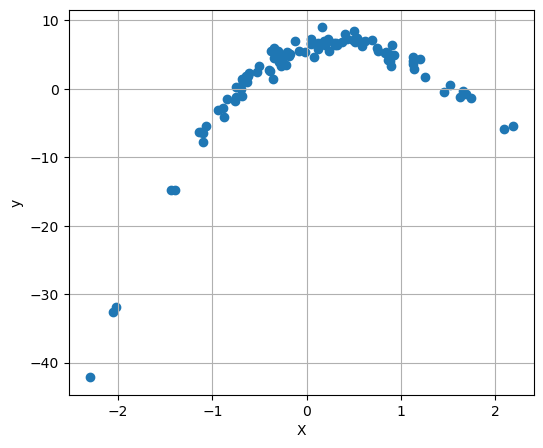

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(x,y)
plt.xlabel("X")
plt.ylabel("y")
plt.grid()

In [8]:
nn = 10
dmatrix = []
for i in range(1, 11):    
    dmatrix.append(np.polynomial.polynomial.polyvander(x,i))


In [10]:
from sklearn.linear_model import LinearRegression

def my_lr(y,dmatrix):
   
    m = len(dmatrix)
    print(m)
    err =[]
    betas = []
    poly = []
    bic = []
    aic = []

    for i in range(m):
        X = dmatrix[i]
        linreg = sm.OLS(y,X).fit()
        ypred = linreg.predict(X)
        mse = mean_squared_error(ypred,y)
        err.append(mse)
        modBeta = linreg.params
        bic.append(linreg.bic)
        aic.append(linreg.aic)
        betas.append(modBeta)
        poly.append(i+1)

    return err, betas, poly, bic, aic

In [11]:
error, betas, poly, bic, aic = my_lr(y,dmatrix)

10


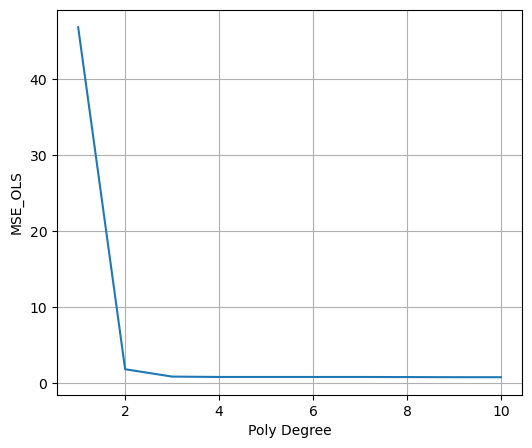

In [15]:
plt.figure(figsize=(6,5))
plt.plot(poly,error)
plt.xlabel("Poly Degree")
plt.ylabel("MSE_OLS")
plt.grid()

In [16]:
print(np.min(aic))
print(aic[3]) #Hence, Polynomial degree with 5 parameters  
print(np.min(bic))
print(bic[3])# Hence, Polynomial degree with 5 parameters  

271.2505374146163
271.2505374146163
284.2763883445568
284.2763883445568


In [17]:
print(poly[3])

4


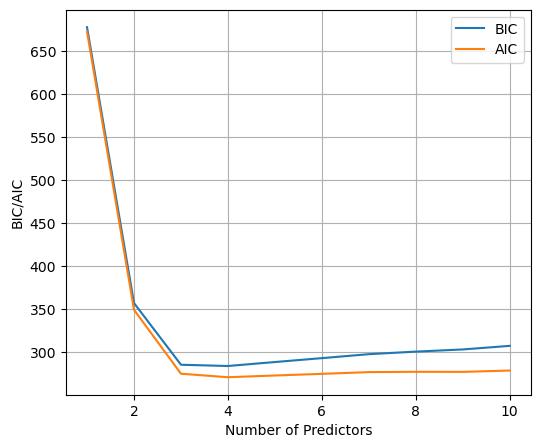

In [18]:
plt.figure(figsize=(6,5))
plt.plot(poly,bic, label = 'BIC')
plt.plot(poly,aic, label = 'AIC')
plt.xlabel("Number of Predictors")
plt.ylabel("BIC/AIC")
plt.legend()
plt.grid()

In [19]:
X_4 = np.polynomial.polynomial.polyvander(x,4) # Polynomial of degree 4.


In [20]:
reg = sm.OLS(y,X_4).fit()
y_fittedOLSBIC = reg.predict(X_4)

In [42]:
x

array([ 1.62434536, -0.61175641, -0.52817175, -1.07296862,  0.86540763,
       -2.3015387 ,  1.74481176, -0.7612069 ,  0.3190391 , -0.24937038,
        1.46210794, -2.06014071, -0.3224172 , -0.38405435,  1.13376944,
       -1.09989127, -0.17242821, -0.87785842,  0.04221375,  0.58281521,
       -1.10061918,  1.14472371,  0.90159072,  0.50249434,  0.90085595,
       -0.68372786, -0.12289023, -0.93576943, -0.26788808,  0.53035547,
       -0.69166075, -0.39675353, -0.6871727 , -0.84520564, -0.67124613,
       -0.0126646 , -1.11731035,  0.2344157 ,  1.65980218,  0.74204416,
       -0.19183555, -0.88762896, -0.74715829,  1.6924546 ,  0.05080775,
       -0.63699565,  0.19091548,  2.10025514,  0.12015895,  0.61720311,
        0.30017032, -0.35224985, -1.1425182 , -0.34934272, -0.20889423,
        0.58662319,  0.83898341,  0.93110208,  0.28558733,  0.88514116,
       -0.75439794,  1.25286816,  0.51292982, -0.29809284,  0.48851815,
       -0.07557171,  1.13162939,  1.51981682,  2.18557541, -1.39

In [21]:
import sklearn as sk
from sklearn.model_selection import KFold
X = x
kf= KFold(n_splits = 10)
kf.get_n_splits(X)

10

In [23]:
kf= KFold(n_splits = 10)
m = kf.get_n_splits(X)
errTest = np.zeros(m)
errTrain = np.zeros(m)


lam = np.linspace(0.0005,0.04,20)
n_lam = len(lam)
errTestMean = np.zeros(n_lam)
errTrainMean = np.zeros(n_lam)
stdTest = np.zeros(n_lam)

for nL in range(n_lam):
    i = 0
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        X_train_transform = np.polynomial.polynomial.polyvander(X_train,10) 
        X_test_transform = np.polynomial.polynomial.polyvander(X_test,10) 
        
        reg = Lasso(alpha = lam[nL], fit_intercept=True,  normalize = True).fit(X_train_transform,y_train)
        
        y_predTrain = reg.predict(X_train_transform)
        y_predTest = reg.predict(X_test_transform)
        
        errTrain[i] = ((y_predTrain - y_train)**2).mean()
        errTest[i] = ((y_predTest - y_test)**2).mean()
        
        i=i+1

    errTestMean[nL]  = errTest.mean()
    stdTest[nL] = errTest.std()
    errTrainMean[nL] = errTrain.mean()

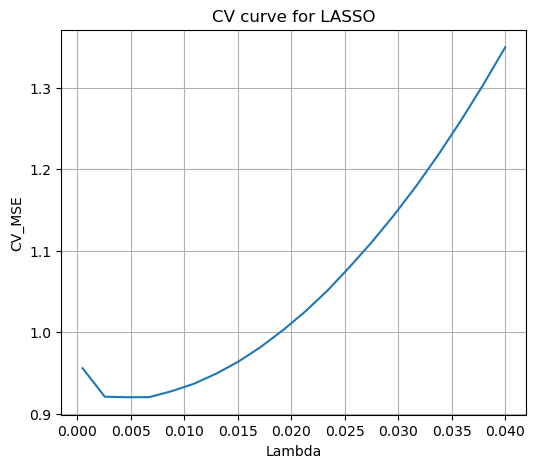

In [24]:
plt.figure(figsize=(6,5))
plt.plot(lam,errTestMean)
plt.xlabel("Lambda")
plt.ylabel("CV_MSE")
plt.title("CV curve for LASSO")
plt.grid()

In [25]:
errTestMean

array([0.95583094, 0.9208234 , 0.92021012, 0.92033047, 0.92758029,
       0.93666183, 0.9489828 , 0.96382189, 0.98167816, 1.00227787,
       1.02514693, 1.05081691, 1.07987667, 1.11050088, 1.14369444,
       1.17945474, 1.21811282, 1.25933765, 1.30326635, 1.34967924])

In [26]:
lam[3]

0.006736842105263157

In [27]:
X = np.polynomial.polynomial.polyvander(x,10) 
reg = Lasso(alpha = lam[3], fit_intercept=True,  normalize = True).fit(X,y)
reg.coef_

array([ 0.        ,  3.84779021, -5.90979283,  0.66838633,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

In [49]:
y_fittedLasso = reg.predict(X)

In [50]:
X = x
m = kf.get_n_splits(X)
errTest = np.zeros(m)
errTrain = np.zeros(m)


lam = np.linspace(0,0.2,20)
n_lam = len(lam)
errTestMean = np.zeros(n_lam)
errTrainMean = np.zeros(n_lam)
stdTest = np.zeros(n_lam)

for nL in range(n_lam):
    i = 0
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        X_train_transform = np.polynomial.polynomial.polyvander(X_train,10) 
        X_test_transform = np.polynomial.polynomial.polyvander(X_test,10) 
        
        model = Ridge(alpha = lam[nL], fit_intercept=True,  normalize = True)
        reg = model.fit(X_train_transform,y_train)
        
        y_predTrain = reg.predict(X_train_transform)
        y_predTest = reg.predict(X_test_transform)
        
        errTrain[i] = ((y_predTrain - y_train)**2).mean()
        errTest[i] = ((y_predTest - y_test)**2).mean()
        
        i=i+1
    errTestMean[nL]  = errTest.mean()
    stdTest[nL] = errTest.std()
    errTrainMean[nL] = errTrain.mean()


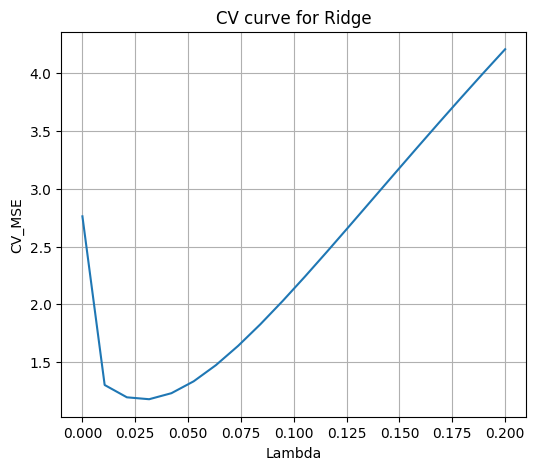

In [51]:
plt.figure(figsize=(6,5))
plt.plot(lam,errTestMean)
plt.xlabel("Lambda")
plt.ylabel("CV_MSE")
plt.title("CV curve for Ridge")
plt.grid()

In [52]:
errTestMean

array([2.76115474, 1.30143716, 1.19475295, 1.17827618, 1.2304284 ,
       1.33321248, 1.47317609, 1.6403608 , 1.82731137, 2.02837363,
       2.23921278, 2.45647864, 2.67756776, 2.90045052, 3.12354314,
       3.34561122, 3.56569613, 3.78305815, 3.9971321 , 4.20749249])

In [53]:
lam[4]

0.042105263157894736

In [54]:
X = np.polynomial.polynomial.polyvander(x,10) 
reg = Ridge(alpha = lam[nL], fit_intercept=True,  normalize = True).fit(X,y)
reg.coef_

array([ 0.00000000e+00,  2.92331897e+00, -3.23070216e+00,  4.37374996e-01,
       -3.45293071e-01,  4.87683624e-02, -3.07437852e-02,  5.37828828e-03,
       -1.50535592e-03,  4.02430261e-04,  3.07803214e-04])

In [55]:
y_fittedRidge = reg.predict(X)

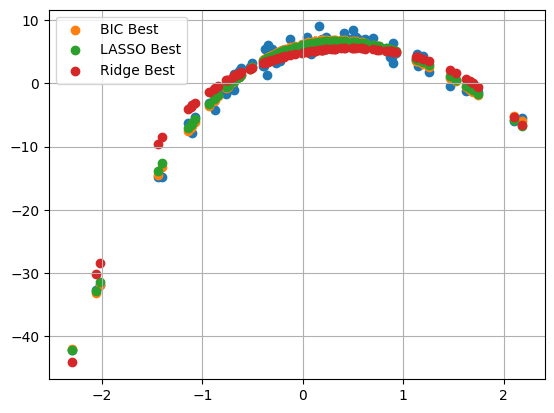

In [56]:
plt.scatter(x,y)
plt.scatter(x,y_fittedOLSBIC, label = 'BIC Best')
plt.scatter(x,y_fittedLasso, label = 'LASSO Best')
plt.scatter(x,y_fittedRidge, label = 'Ridge Best')
plt.legend()
plt.grid()